# 02 - Instance Segmentation

Ejemplos para modelos `*-seg.pt`: lectura de poligonos, filtrado y ploteo directo de mascaras.


In [ ]:
from pathlib import Path
import sys

cwd = Path.cwd()
if (cwd / "vision").exists():
    PROJECT_ROOT = cwd
elif len(cwd.parents) >= 3 and (cwd.parents[2] / "vision").exists():
    PROJECT_ROOT = cwd.parents[2]
else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

NOTEBOOK_DIR = PROJECT_ROOT / "vision" / "yolo" / "notebooks"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

IMAGE = str(NOTEBOOK_DIR / "input" / "29136178007_c9ddfb15cb_b.jpg")

from vision.yolo.infer import predict_image
from vision.yolo.plotting import (
    plot_segmentation_masks,
    plot_image_detections,
    plot_class_distribution,
)

MODEL = (
    str(NOTEBOOK_DIR / "yolo11n-seg.pt")
    if (NOTEBOOK_DIR / "yolo11n-seg.pt").exists()
    else "yolo11n-seg.pt"
)


In [ ]:
df = predict_image(MODEL, IMAGE, confidence=0.25, task="segment")
print(
    df[
        ["frame", "class_name", "confidence", "xmin", "ymin", "xmax", "ymax", "polygon"]
    ].head()
)


   frame class_name  confidence        xmin       ymin        xmax  \
0      0     person    0.890628  122.166801  52.616993  458.614471   

          ymax                                            polygon  
0  1016.765076  [[281.6000061035156, 54.400001525878906], [281...  


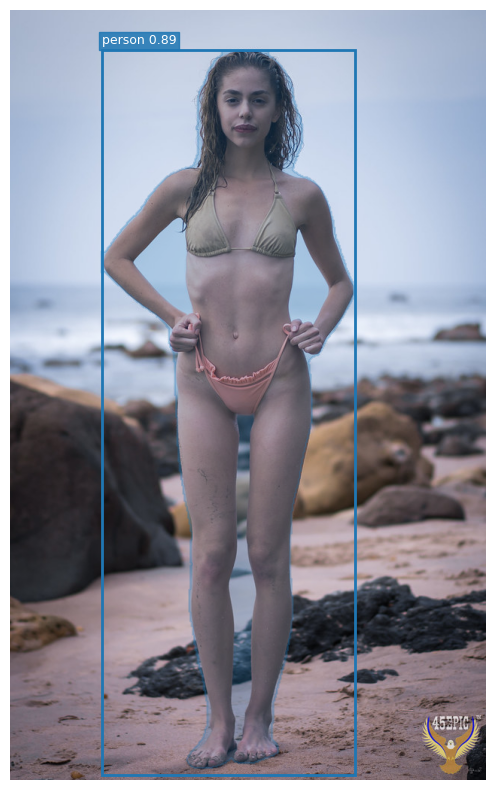

In [ ]:
# Plot directo de mascaras + cajas
plot_segmentation_masks(
    IMAGE,
    df,
    draw_boxes=True,
    confidence_threshold=0.25,
    save_to=OUTPUT_DIR / "02_segmentation_masks.png",
)


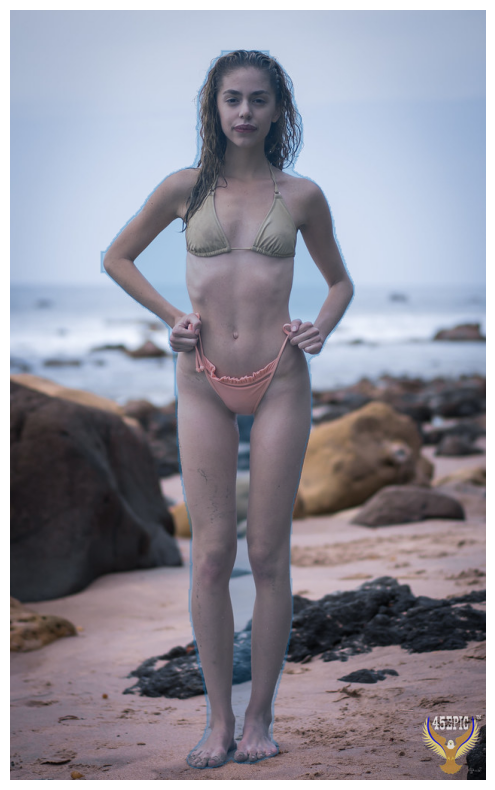

In [ ]:
# Solo poligonos, sin cajas
plot_segmentation_masks(
    IMAGE,
    df,
    draw_boxes=False,
    draw_labels=False,
    save_to=OUTPUT_DIR / "02_polygons_only.png",
)


In [ ]:
# Inspeccion de vertices por deteccion
with_polygons = df[df["polygon"].notna()].copy()
with_polygons["n_vertices"] = with_polygons["polygon"].apply(
    lambda p: len(p) if isinstance(p, list) else 0
)
print(with_polygons[["class_name", "confidence", "n_vertices"]].head())


  class_name  confidence  n_vertices
0     person    0.890628         480


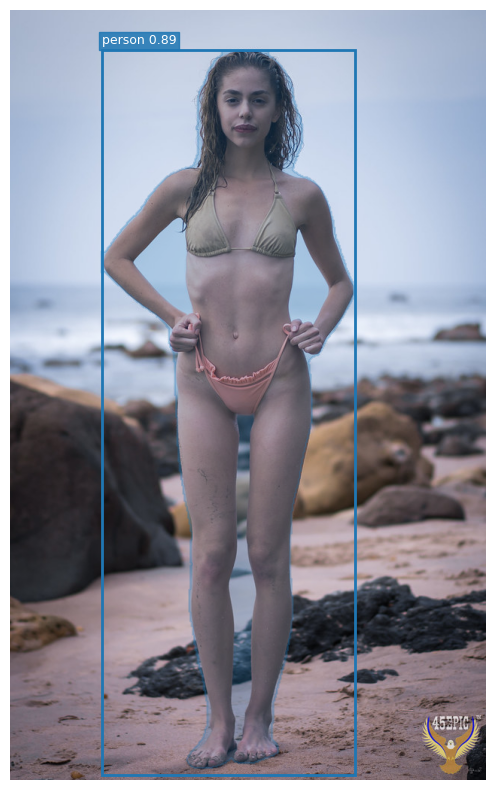

In [ ]:
# Filtrar una clase o una confianza antes del plot
filtered = df[df["confidence"].ge(0.45)]
plot_image_detections(
    IMAGE,
    filtered,
    draw_boxes=True,
    draw_polygons=True,
    draw_keypoints=False,
    save_to=OUTPUT_DIR / "02_filtered_segments.png",
)


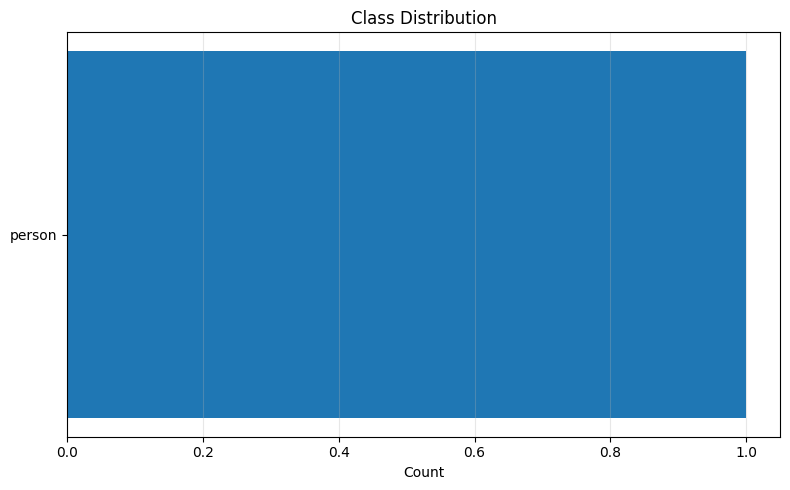

In [ ]:
plot_class_distribution(df, save_to=OUTPUT_DIR / "02_class_distribution.png")


,frame,track_id,class_id,class_name,confidence,xmin,ymin,xmax,ymax,polygon,mask,keypoints,timestamp
0,0,None,0,person,0.890628,122.166801,52.616993,458.614471,1016.765076,"[[281.6000061035156, 54.400001525878906], [281...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",None,None


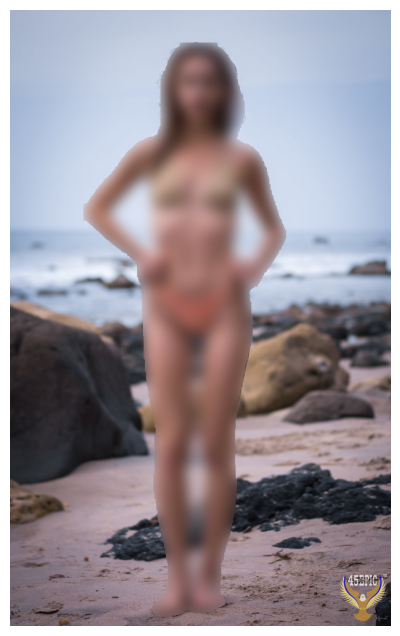

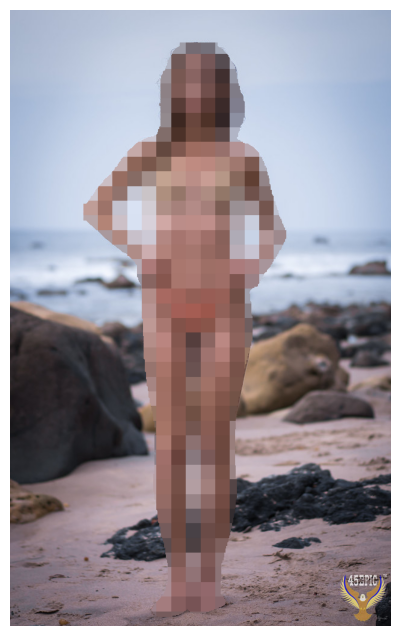

In [ ]:
from PIL import Image, ImageFilter, ImageDraw
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# create a df only for "people"
people = df[df["class_name"] == "person"].copy()

display(people.head())

img = Image.open(IMAGE).convert("RGB")


def polygon_points(poly):
    if poly is None:
        return None
    arr = np.asarray(poly)
    if arr.size == 0:
        return None
    if arr.ndim == 1:
        arr = arr.reshape(-1, 2)
    return [(int(round(x)), int(round(y))) for x, y in arr[:, :2]]


def make_polygon_mask(size, points):
    mask = Image.new("L", size, 0)
    draw = ImageDraw.Draw(mask)
    draw.polygon(points, fill=255)
    return mask


# --- blurred mask ---
img_blur = img.copy()
blurred_full = img.filter(ImageFilter.GaussianBlur(radius=10))

for _, row in people.iterrows():
    points = polygon_points(row["polygon"])
    if not points:
        continue
    mask = make_polygon_mask(img.size, points)
    img_blur = Image.composite(blurred_full, img_blur, mask)

plt.figure(figsize=(12, 8))
plt.imshow(img_blur)
plt.axis("off")
plt.show()


# --- pixelated mask ---
img_pixel = img.copy()
small_w, small_h = max(1, img.width // 24), max(1, img.height // 24)
pixelated_full = img.resize((small_w, small_h), resample=Image.BILINEAR).resize(
    img.size, resample=Image.NEAREST
)

for _, row in people.iterrows():
    points = polygon_points(row["polygon"])
    if not points:
        continue
    mask = make_polygon_mask(img.size, points)
    img_pixel = Image.composite(pixelated_full, img_pixel, mask)

plt.figure(figsize=(12, 8))
plt.imshow(img_pixel)
plt.axis("off")
plt.show()
